In [1]:
import os
os.chdir(r"C:\Users\mpree\cfpb-classifier")
print(os.getcwd())

C:\Users\mpree\cfpb-classifier


In [5]:
pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score,f1_score,classification_report

In [9]:
with open('saved_models/preprocessed_data.pkl','rb') as f:
    data=pickle.load(f)
X_train=data['X_train']
X_val=data['X_val']
X_test=data['X_test']
y_train=data['y_train']
y_val=data['y_val']
y_test=data['y_test']
num_classes=data['num_classes']
le=data['le']

print("Data loaded")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Data loaded
Train: 36000 | Val: 4000 | Test: 10000


In [19]:
VOCAB_SIZE=20000
MAX_LEN=128

tokenizer=Tokenizer(num_words=VOCAB_SIZE,oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_enc=pad_sequences(tokenizer.texts_to_sequences(X_train),maxlen=MAX_LEN,padding='post',truncating='post')
X_val_enc=pad_sequences(tokenizer.texts_to_sequences(X_val),maxlen=MAX_LEN,padding='post',truncating='post')
X_test_enc=pad_sequences(tokenizer.texts_to_sequences(X_test),maxlen=MAX_LEN,padding='post',truncating='post')

print(f"X_train shape : {X_train_enc.shape}")
print(f"X_val shape   : {X_val_enc.shape}")
print(f"X_test shape  :  {X_test_enc.shape}")

X_train shape : (36000, 128)
X_val shape   : (4000, 128)
X_test shape  :  (10000, 128)


In [13]:
EMBED_DIM=100
embeddings_index={}
with open('glove.6B.100d.txt',encoding='utf-8') as f:
    for line in f:
        values=line.split()
        word=values[0]
        vector=np.asarray(values[1:],dtype='float32')
        embeddings_index[word]=vector
print(f"GloVe loaded: {len(embeddings_index)} vectors")

embedding_matrix=np.zeros((VOCAB_SIZE,EMBED_DIM))
word_index=tokenizer.word_index

for word,i in word_index.items():
    if i<VOCAB_SIZE:
        vector=embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[i]=vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

GloVe loaded: 400000 vectors
Embedding matrix shape: (20000, 100)


In [23]:
def build_rnn():
    model=models.Sequential([
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=True
        ),
        layers.SimpleRNN(128,return_sequences=False),
        layers.BatchNormalization(),
        layers.Dense(64,activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes,activation='softmax')
    ])
    return model

rnn_model=build_rnn()
rnn_model.summary()

C:\Users\mpree\anaconda3\envs\demo\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=2, restore_best_weights=True
)

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1 — Training with frozen embeddings...")
history1 = rnn_model.fit(
    X_train_enc, y_train,
    validation_data=(X_val_enc, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Phase 1 — Training with frozen embeddings...
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.2271 - loss: 1.6411 - val_accuracy: 0.2230 - val_loss: 1.6091
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.2515 - loss: 1.5704 - val_accuracy: 0.2407 - val_loss: 1.8421
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.2663 - loss: 1.5522 - val_accuracy: 0.2050 - val_loss: 2.4819


In [27]:
pip install optuna

  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 2.8 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 2.7 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.5 MB/s  0:00:00
Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl (154 kB)
   ---------------------------------------- 0.0/676.7 kB ? eta -:--:--
   --------------- ------------------------ 262.1/676.7 kB ? eta -:--:--
   ---------------------------------------- 676.7/676.7 kB 2.0 MB/s  0:00:00

   ---------------------------------------- 0/9 [tqdm]
   ------------- -------------------------- 3/9 [greenlet]
   ------------- -------------------------- 3/9 [greenlet]
   ---------------------- -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [29]:

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\Users\mpree\anaconda3\envs\demo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
def build_tuned_rnn(trial):
    units=trial.suggest_categorical('units',  [64,128,256])
    dropout=trial.suggest_float('dropout',0.1,0.5)
    lr=trial.suggest_float('lr',1e-4,1e-2,log=True)
    max_len=trial.suggest_categorical('max_len',[64,128,256])
    batch_size=trial.suggest_categorical('batch_size',[32,64,128])

    X_tr=pad_sequences(tokenizer.texts_to_sequences(X_train),maxlen=max_len,padding='post',truncating='post')
    X_v=pad_sequences(tokenizer.texts_to_sequences(X_val),maxlen=max_len,padding='post',truncating='post')

    model=models.Sequential([
         layers.Embedding(
              input_dim=VOCAB_SIZE,
              output_dim=EMBED_DIM,
              weights=[embedding_matrix],
              input_length=max_len,
              trainable=True
         ),
         layers.SimpleRNN(units),
         layers.Dropout(dropout),
         layers.Dense(num_classes,activation='softmax')
    ])

    model.compile(
         optimizer=tf.keras.optimizers.Adam(lr,clipnorm=1.0),
         loss='sparse_categorical_crossentropy',
         metrics=['accuracy']
    )

    model.fit(
        X_tr,y_train,validation_data=(X_v,y_val),epochs=5,batch_size=batch_size,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)],verbose=0)
    return model.evaluate(X_v,y_val,verbose=0)[1]

In [46]:
study=optuna.create_study(direction='maximize')
study.optimize(build_tuned_rnn,n_trials=5)
print(f"\nBest Val Accuracy : {study.best_value:.4f}")
print(f"Best Params :{study.best_params}")


Best Val Accuracy : 0.7207
Best Params :{'units': 64, 'dropout': 0.10681758958611472, 'lr': 0.0007944234225748883, 'max_len': 64, 'batch_size': 128}


Training final RNN with best params: {'units': 64, 'dropout': 0.10681758958611472, 'lr': 0.0007944234225748883, 'max_len': 64, 'batch_size': 128}
Epoch 1/10


C:\Users\mpree\anaconda3\envs\demo\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3228 - loss: 1.5004 - val_accuracy: 0.4092 - val_loss: 1.3156
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4684 - loss: 1.2346 - val_accuracy: 0.5305 - val_loss: 1.0657
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5389 - loss: 1.0966 - val_accuracy: 0.5505 - val_loss: 1.0444
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5788 - loss: 1.0290 - val_accuracy: 0.6355 - val_loss: 0.9335
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6766 - loss: 0.9116 - val_accuracy: 0.7060 - val_loss: 0.9154
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7260 - loss: 0.8552 - val_accuracy: 0.7475 - val_loss: 0.8196
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7533 - loss: 0.7958 - val_accuracy: 0.7247 - val_loss: 0.8698
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7594 - loss: 0.7828 - val_accuracy: 0.772

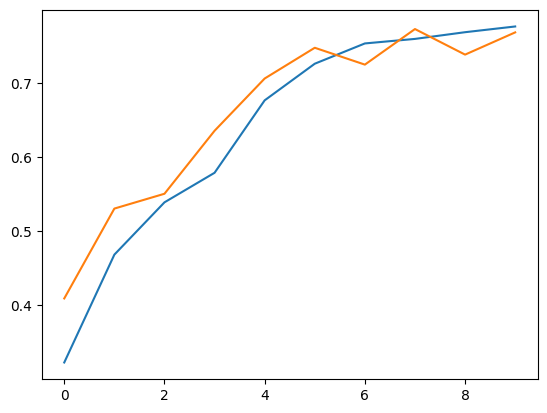

In [56]:
best=study.best_params
MAX_LEN_B=best['max_len']

X_train_enc=pad_sequences(tokenizer.texts_to_sequences(X_train),maxlen=MAX_LEN_B,padding='post',truncating='post')
X_val_enc=pad_sequences(tokenizer.texts_to_sequences(X_val),maxlen=MAX_LEN_B,padding='post',truncating='post')
X_test_enc=pad_sequences(tokenizer.texts_to_sequences(X_test),maxlen=MAX_LEN_B,padding='post',truncating='post')

final_rnn=models.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN_B,
        trainable=True
    ),
    layers.SimpleRNN(best['units']),
    layers.Dropout(best['dropout']),
    layers.Dense(num_classes,activation='softmax')
])
final_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(best['lr'],clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Training final RNN with best params: {best}")
history=final_rnn.fit(
    X_train_enc,y_train,
    validation_data=(X_val_enc,y_val),
    epochs=10,
    batch_size=best['batch_size'],
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)]
)
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')


In [58]:
from sklearn.metrics import accuracy_score,f1_score,classification_report
preds=np.argmax(final_rnn.predict(X_test_enc),axis=1)
rnn_acc=accuracy_score(y_test,preds)
rnn_f1=f1_score(y_test,preds,average='macro')

print("RNN FINAL RESULTS")
print(f"Test Accuracy :{rnn_acc:.4f}")
print(f"Test F1_Score : {rnn_f1:.4f}")
print(f"\nDetailed Report :")
print(classification_report(y_test,preds,target_names=le.classes_))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RNN FINAL RESULTS
Test Accuracy :0.7668
Test F1_Score : 0.7656

Detailed Report :
                     precision    recall  f1-score   support

        credit_card       0.71      0.74      0.73      2000
   credit_reporting       0.79      0.71      0.74      2000
    debt_collection       0.78      0.69      0.73      2000
mortgages_and_loans       0.78      0.85      0.81      2000
     retail_banking       0.78      0.84      0.81      2000

           accuracy                           0.77     10000
          macro avg       0.77      0.77      0.77     10000
       weighted avg       0.77      0.77      0.77     10000



In [60]:
import pickle
final_rnn.save('saved_models/rnn_model.h5')
with open('saved_models/results.pkl','rb') as f:
    results=pickle.load(f)
results['rnn_acc']=rnn_acc
results['rnn_f1']=rnn_f1

with open('saved_models/results.pkl','wb') as f:
    pickle.dump(results,f)
print("RNN MODEL SAVED")
print(f"Accuracy :{rnn_acc:.4f}")
print(f"F  : {rnn_f1:.4f}")

RNN MODEL SAVED
Accuracy :0.7668
F  : 0.7656
